In [45]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Project Dataset : "Customer Transaction Prediction Model"
Domain : Retail

In [46]:
df = pd.read_csv(r"D:\datasets\Internship_Projects\Customer_Transaction_Data\Mall_Transaction.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I100008,C199951,Male,65,Clothing,5,1500.40,Cash,10-07-2022,Emaar Square Mall
1,I100014,C138893,Male,55,Cosmetics,5,203.30,Cash,18-06-2021,Viaport Outlet
2,I100015,C132779,Female,35,Clothing,2,600.16,Debit Card,04-03-2021,Mall of Istanbul
3,I100024,C244411,Female,67,Books,3,45.45,Credit Card,05-01-2023,Emaar Square Mall
4,I100027,C150002,Female,19,Technology,4,4200.00,Cash,18-05-2022,Mall of Istanbul


In [47]:
df.shape

(99457, 10)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


In [49]:
df.describe(include='all')

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457.000000,99457,99457.000000,99457.000000,99457,99457,99457
unique,99457,99457,2,NaN,8,NaN,NaN,3,797,10
top,I100008,C199951,Female,NaN,Clothing,NaN,NaN,Cash,24-11-2021,Mall of Istanbul
freq,1,1,59482,NaN,34487,NaN,NaN,44447,159,19943
mean,NaN,NaN,NaN,43.427089,NaN,3.003429,689.256321,NaN,NaN,NaN
std,NaN,NaN,NaN,14.990054,NaN,1.413025,941.184567,NaN,NaN,NaN
min,NaN,NaN,NaN,18.000000,NaN,1.000000,5.230000,NaN,NaN,NaN
25%,NaN,NaN,NaN,30.000000,NaN,2.000000,45.450000,NaN,NaN,NaN
50%,NaN,NaN,NaN,43.000000,NaN,3.000000,203.300000,NaN,NaN,NaN
75%,NaN,NaN,NaN,56.000000,NaN,4.000000,1200.320000,NaN,NaN,NaN


In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

# EDA (Exploratery Data Analysis) :

# Histogram - "Price Distribution"

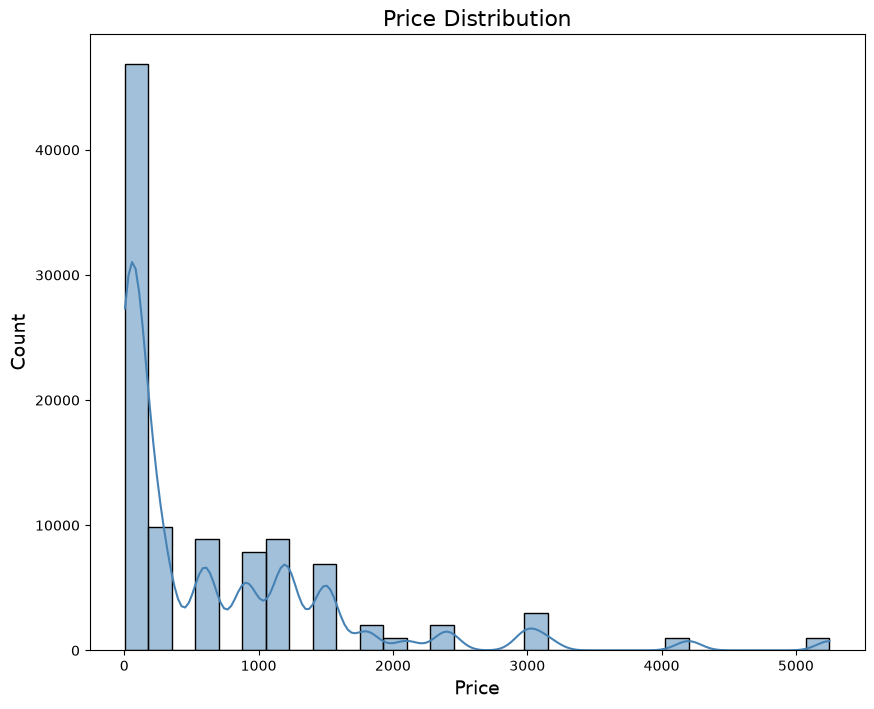

In [52]:
plt.figure(figsize=(10, 8))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Price Distribution", fontsize=16)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()

# Age distribution

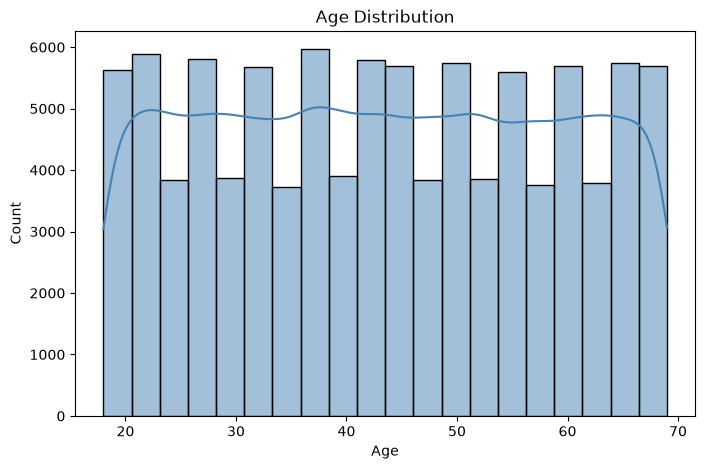

In [53]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Payment method count

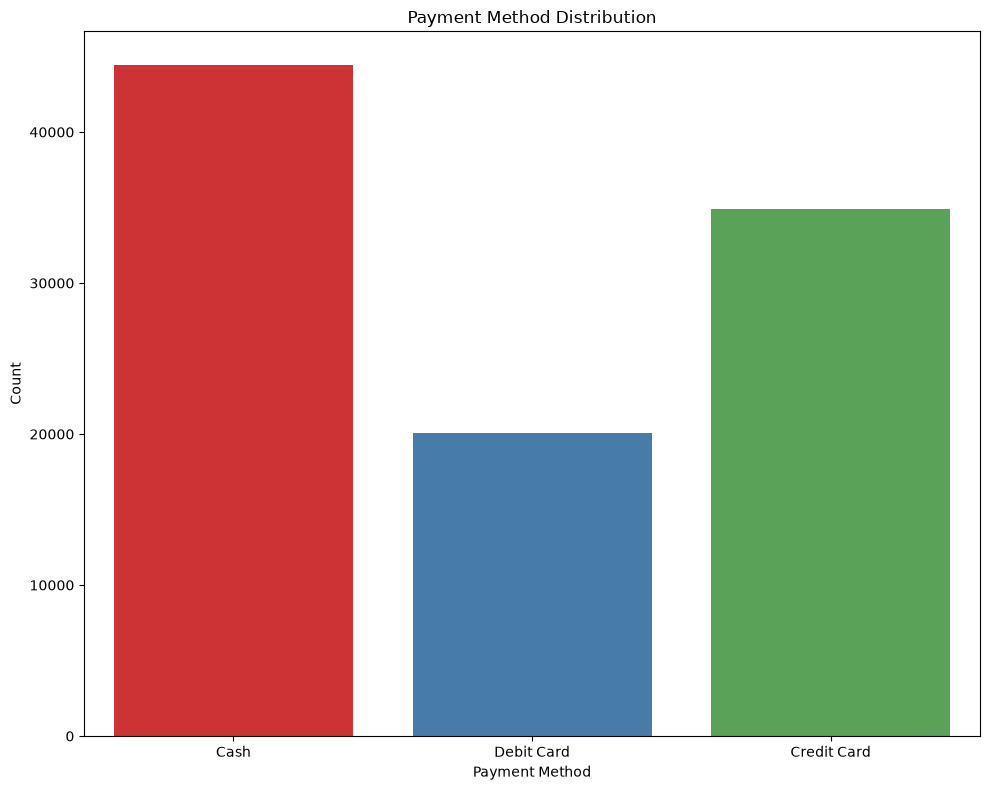

In [54]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x="payment_method", palette="Set1")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Shopping mall count

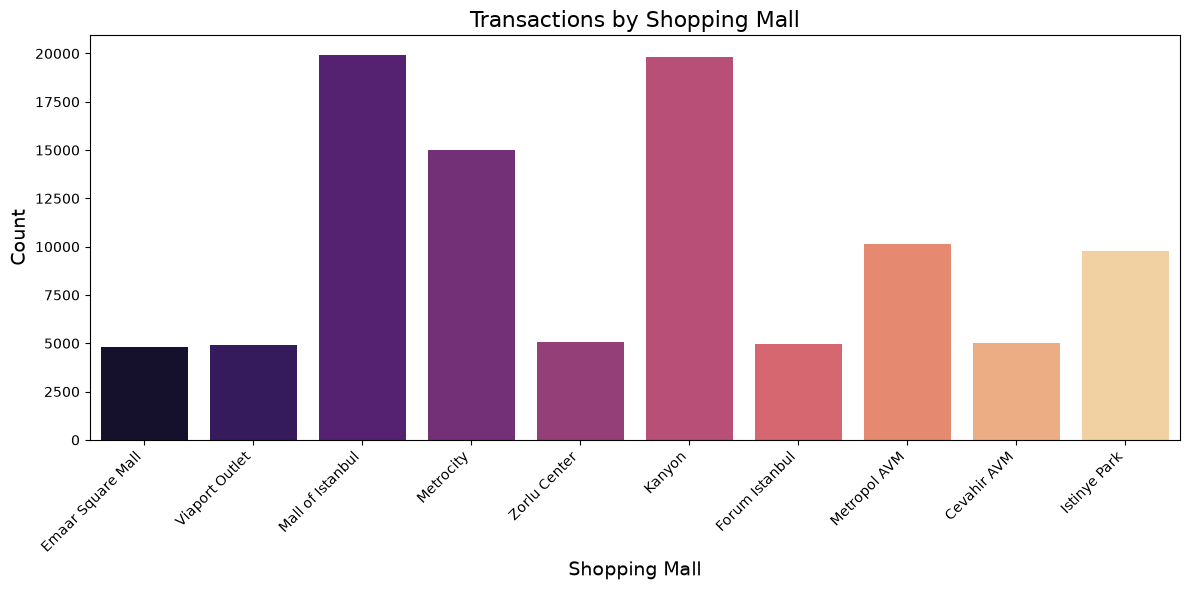

In [55]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="shopping_mall", palette="magma")
plt.xticks(rotation=45, ha="right")
plt.title("Transactions by Shopping Mall", fontsize=16)
plt.xlabel("Shopping Mall", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.tight_layout()
plt.show()

# Plot monthly sales

# Monthly Sales

In [56]:
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    format="%d-%m-%Y"
)

# Sales per transaction
df["sales"] = df["quantity"] * df["price"]

# Total sales by month, in chronological order
monthly_sales = (
    df.set_index("invoice_date")["sales"]
      .resample("MS")
      .sum()
      .rename("monthly_sales")
      .to_frame()
)

# Difference from the previous month
monthly_sales["sales_difference"] = monthly_sales["monthly_sales"].diff()

pd.DataFrame(monthly_sales)

,monthly_sales,sales_difference
invoice_date,,
2021-01-01,9641614.62,NaN
2021-02-01,8772315.22,-869299.40
2021-03-01,9455359.38,683044.16
2021-04-01,9389541.54,-65817.84
2021-05-01,9771756.97,382215.43
2021-06-01,9286271.35,-485485.62
2021-07-01,10311119.68,1024848.33
2021-08-01,9630655.70,-680463.98
2021-09-01,9188165.62,-442490.08


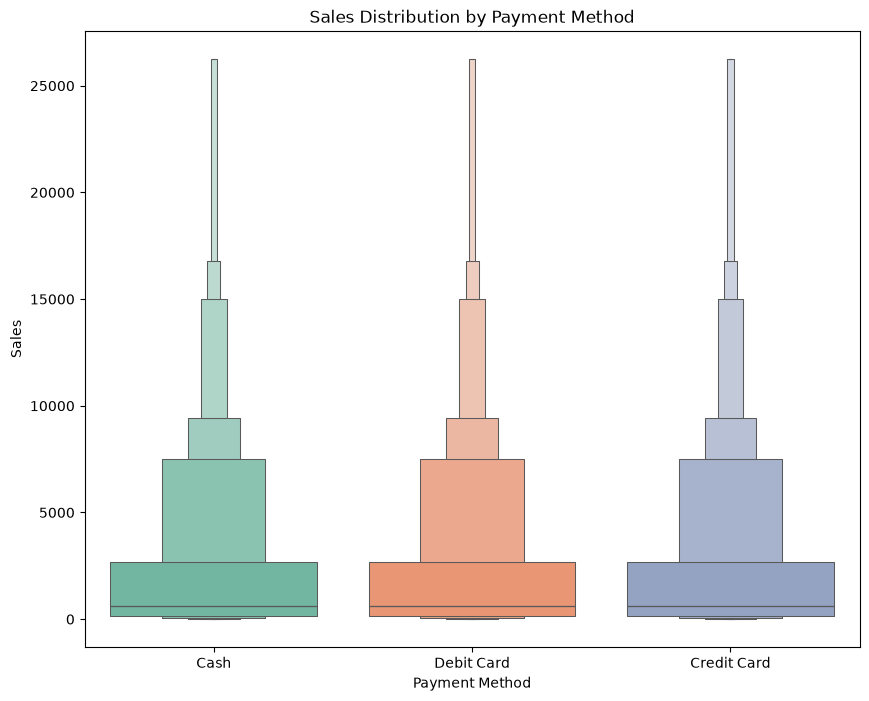

In [57]:
plt.figure(figsize=(10,8))
sns.boxenplot(data=df, x="payment_method", y="sales", palette="Set2")
plt.title("Sales Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales")
plt.show()

# DATA Cleaning

In [58]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [59]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall', 'sales'],
      dtype='str')

In [60]:
df.drop(columns=['invoice_no', 'customer_id','invoice_date'],inplace=True)


In [61]:
df.head()

,gender,age,category,quantity,price,payment_method,shopping_mall,sales
0,Male,65,Clothing,5,1500.40,Cash,Emaar Square Mall,7502.00
1,Male,55,Cosmetics,5,203.30,Cash,Viaport Outlet,1016.50
2,Female,35,Clothing,2,600.16,Debit Card,Mall of Istanbul,1200.32
3,Female,67,Books,3,45.45,Credit Card,Emaar Square Mall,136.35
4,Female,19,Technology,4,4200.00,Cash,Mall of Istanbul,16800.00


In [62]:
le = LabelEncoder()

In [63]:
df[df.select_dtypes(include='object').columns]=df[df.select_dtypes(include='object').columns].apply(le.fit_transform)

In [64]:
df.head()

,gender,age,category,quantity,price,payment_method,shopping_mall,sales
0,1,65,1,5,1500.40,0,1,7502.00
1,1,55,2,5,203.30,0,8,1016.50
2,0,35,1,2,600.16,2,5,1200.32
3,0,67,0,3,45.45,1,1,136.35
4,0,19,6,4,4200.00,0,5,16800.00


In [65]:
df_train, df_test =train_test_split(df, test_size=0.2, random_state=42)

In [67]:
df_train_x =df_train.drop(columns=['sales'])
df_train_y =df_train['sales']

# Model Evaluation :

In [72]:
log_model=LogisticRegression()